# AIC / PIC across Passive, Repeat, Decision

Compare **AIC** vs **PIC** waveforms under `Passive` / `Repeat` / `Decision`
using a **fixed electrode set** per subject:

1. Collect significant channels from `epoch(band)(sig)` across **all phases ×
   conditions** for that subject.
2. Restrict the union to Hammers `AIC` / `PIC` (from packaged `*_coord.csv`).
3. Read matching `epoch(band)(zscore)` files, `.pick` the union, average
   trials, and plot — **no new CSV packaging**.

Figures are inline only. Style follows
[`docs/PLOTTING_STYLE.md`](../docs/PLOTTING_STYLE.md).

> Loading all tasks reads many H5 files — prefer a compute node / interactive
> Slurm session rather than the login node.

In [9]:
%matplotlib inline

from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from mne_bids import BIDSPath
from tqdm.auto import tqdm

In [10]:
cm = 1 / 2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'

cond_colors = {
    'Passive': '#00753f',
    'Repeat': '#a9373b',
    'Decision': '#5c4ebd',
}

## Config

Channel inclusion = **union of sig channels across all listed conditions and
phases** within each subject, then intersected with Hammers AIC/PIC.

| Condition | Typical tasks |
|-----------|---------------|
| Passive | LexicalNoDelay, PictureNaming |
| Repeat | LexicalDelay, LexicalNoDelay, PictureNaming, PhonemeSequence |
| Decision | LexicalDelay, LexicalNoDelay |

In [11]:
ROOT = Path('..').resolve()
RESULTS_ROOT = ROOT / 'results'

TASK_BIDS = {
    'LexicalDelay': '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS',
    'LexicalNoDelay': '/cwork/ns458/BIDS-1.0_LexicalDecRepNoDelay/BIDS',
    'PhonemeSequence': '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS',
    'PictureNaming': '/cwork/ns458/BIDS-1.3_PictureNaming/BIDS',
}

TASKS = list(TASK_BIDS)

ROIS = ['AIC', 'PIC']
DESCRIPTIONS = ['Passive', 'Repeat', 'Decision']
PHASES = ['stimulus', 'delay', 'go', 'response']

REF = 'bipolar'
ATLAS = 'hammers'
BAND = 'highgamma'
MODALITY = 'sound'  # PictureNaming also has image/text
HEMI = None  # 'L', 'R', or None
EXCLUDE_SUBJECTS = {'D0121'}

TIME_MAX = 1.5

## Helpers

- **Coords**: Hammers `*_coord.csv` → `channel → roi / hemi / mix`
- **Sig union**: `epoch(band)(sig)` channel names across condition × phase
- **Waveforms**: average `epoch(band)(zscore)` after picking the union

In [12]:
def _norm_phase(phase: str) -> str:
    p = str(phase)
    if p == 'Resp':
        p = 'Response'
    elif p == 'Audio':
        p = 'Stimulus'
    return p.lower()


def _norm_subject(subject: str) -> str:
    return subject.removeprefix('sub-')


def _modality_of(path) -> str:
    return path.recording if path.recording is not None else 'sound'


def epoch_root(bids_root: str) -> str:
    return str(Path(bids_root) / f'derivatives/epoch({REF})')


def load_coord_meta(tasks=TASKS) -> pd.DataFrame:
    """Unique (subject, channel) → roi / hemi / mix / label from hammers coords."""
    paths = []
    for task in tasks:
        root = RESULTS_ROOT / f'{task}({REF})({ATLAS})'
        if not root.exists():
            print(f'[skip coords] missing {root}')
            continue
        paths.extend(
            BIDSPath(root=str(root), datatype='HGA', suffix='coord', check=False).match()
        )
    if not paths:
        raise FileNotFoundError('No hammers *_coord.csv found under results/')

    frames = []
    for path in tqdm(paths, desc='load coords'):
        df = pd.read_csv(path)
        keep = [c for c in ('channel', 'roi', 'hemi', 'mix', 'label', 'subject') if c in df.columns]
        frames.append(df[keep])
    meta = pd.concat(frames, ignore_index=True)
    meta['subject'] = meta['subject'].map(_norm_subject)
    meta = meta.drop_duplicates(subset=['subject', 'channel'], keep='first')

    meta = meta[meta['roi'].isin(ROIS)].copy()
    if 'mix' in meta.columns:
        meta = meta[meta['mix'] == False]
    if 'label' in meta.columns:
        meta = meta[meta['label'].astype(str) != '0']
    if HEMI is not None:
        meta = meta[meta['hemi'] == HEMI]
    meta = meta[~meta['subject'].isin(EXCLUDE_SUBJECTS)]
    return meta.reset_index(drop=True)


def list_sig_paths(bids_root: str):
    return BIDSPath(
        root=epoch_root(bids_root),
        datatype='epoch(band)(sig)',
        suffix=BAND,
        extension='.h5',
        check=False,
    ).match()


def list_zscore_paths(bids_root: str):
    return BIDSPath(
        root=epoch_root(bids_root),
        datatype='epoch(band)(zscore)',
        suffix=BAND,
        extension='.h5',
        check=False,
    ).match()


def sig_union_by_subject(sig_paths, descriptions=DESCRIPTIONS) -> dict[str, set[str]]:
    """subject → ∪ channel names over all matching condition × phase sig files."""
    by_subj: dict[str, set[str]] = defaultdict(set)
    for path in tqdm(sig_paths, desc='sig union'):
        if path.description not in descriptions:
            continue
        if _modality_of(path) != MODALITY:
            continue
        subj = _norm_subject(path.subject)
        if subj in EXCLUDE_SUBJECTS:
            continue
        epochs = mne.read_epochs(path, preload=False, verbose=False)
        by_subj[subj].update(epochs.ch_names)
    return dict(by_subj)


def evoked_to_long(epochs, channels: list[str]) -> pd.DataFrame | None:
    """Trial-average → long (time, channel, value). Avoids mne to_data_frame spam."""
    picks = [ch for ch in channels if ch in epochs.ch_names]
    if not picks:
        return None
    epo = epochs.copy().pick(picks)
    data = np.nanmean(epo.get_data(copy=False), axis=0)  # (n_ch, n_times)
    times = epo.times
    n_ch, n_t = data.shape
    return pd.DataFrame({
        'time': np.tile(times, n_ch),
        'channel': np.repeat(list(epo.ch_names), n_t),
        'value': data.reshape(-1),
    })


def load_task_waveforms(
    task: str,
    coord_meta: pd.DataFrame,
    *,
    descriptions=DESCRIPTIONS,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Return (long HGA df, per-subject union QC table) for one task."""
    bids_root = TASK_BIDS[task]
    sig_paths = list_sig_paths(bids_root)
    z_paths = list_zscore_paths(bids_root)
    if not sig_paths or not z_paths:
        raise FileNotFoundError(f'{task}: missing sig/zscore epochs under {bids_root}')

    unions = sig_union_by_subject(sig_paths, descriptions=descriptions)

    # Restrict union to AIC/PIC contacts present in hammers coords
    roi_by_subj = {
        subj: set(g['channel'])
        for subj, g in coord_meta.groupby('subject')
    }
    channel_roi = coord_meta.set_index(['subject', 'channel'])['roi'].to_dict()
    channel_hemi = (
        coord_meta.set_index(['subject', 'channel'])['hemi'].to_dict()
        if 'hemi' in coord_meta.columns
        else {}
    )

    qc_rows = []
    restricted: dict[str, list[str]] = {}
    for subj, chans in unions.items():
        keep = sorted(chans & roi_by_subj.get(subj, set()))
        restricted[subj] = keep
        qc_rows.append({
            'task': task,
            'subject': subj,
            'n_sig_union': len(chans),
            'n_aic_pic_union': len(keep),
            'n_aic': sum(1 for ch in keep if channel_roi.get((subj, ch)) == 'AIC'),
            'n_pic': sum(1 for ch in keep if channel_roi.get((subj, ch)) == 'PIC'),
        })
    qc = pd.DataFrame(qc_rows)

    rows = []
    for path in tqdm(z_paths, desc=f'zscore {task}'):
        if path.description not in descriptions:
            continue
        if _modality_of(path) != MODALITY:
            continue
        subj = _norm_subject(path.subject)
        if subj in EXCLUDE_SUBJECTS:
            continue
        picks = restricted.get(subj)
        if not picks:
            continue

        epochs = mne.read_epochs(path, preload=True, verbose=False)
        df = evoked_to_long(epochs, picks)
        del epochs
        if df is None or df.empty:
            continue

        df['subject'] = subj
        df['description'] = path.description
        df['task'] = task
        df['phase'] = _norm_phase(path.processing)
        df['modality'] = _modality_of(path)
        df['roi'] = [channel_roi.get((subj, ch)) for ch in df['channel']]
        df['hemi'] = [channel_hemi.get((subj, ch)) for ch in df['channel']]
        rows.append(df)

    if not rows:
        return pd.DataFrame(), qc
    out = pd.concat(rows, ignore_index=True)
    out = out[out['roi'].isin(ROIS) & (out['time'] < TIME_MAX)].copy()
    return out, qc

## Load waveforms (sig-union → zscore)

Per subject, the same AIC/PIC channel set is used for every condition and phase
that exists in that task.

In [ ]:
coord_meta = load_coord_meta(TASKS)
print(
    f'Coord AIC/PIC contacts: {len(coord_meta):,} | '
    f'subjects={coord_meta.subject.nunique()} | '
    f'AIC={coord_meta.roi.eq("AIC").sum()} PIC={coord_meta.roi.eq("PIC").sum()}'
)

hga_parts = []
qc_parts = []
for task in TASKS:
    print(f'\n=== {task} ===')
    part, qc = load_task_waveforms(task, coord_meta)
    print(
        f'  rows={len(part):,} | subjects={part.subject.nunique() if len(part) else 0} | '
        f'conditions={sorted(part.description.unique()) if len(part) else []}'
    )
    if len(part):
        hga_parts.append(part)
    if len(qc):
        qc_parts.append(qc)

HGAs = pd.concat(hga_parts, ignore_index=True) if hga_parts else pd.DataFrame()
union_qc = pd.concat(qc_parts, ignore_index=True) if qc_parts else pd.DataFrame()

print(f'\nTotal rows: {len(HGAs):,}')
if len(HGAs):
    print(f'Tasks: {sorted(HGAs.task.unique())}')
    print(f'Descriptions: {sorted(HGAs.description.unique())}')
    print(f'Phases: {sorted(HGAs.phase.unique())}')
    print(f'AIC channels: {HGAs.loc[HGAs.roi == "AIC", "channel"].nunique()}')
    print(f'PIC channels: {HGAs.loc[HGAs.roi == "PIC", "channel"].nunique()}')
HGAs.head()

## Coverage QC

Left: mean AIC/PIC union size per task. Right: channels present in the plotted
long table (should be stable across conditions within a subject).

In [14]:
plot_df = HGAs.copy()

if len(union_qc):
    display_qc = (
        union_qc.groupby('task', observed=True)[['n_sig_union', 'n_aic_pic_union', 'n_aic', 'n_pic']]
        .mean()
        .round(1)
        .reindex(TASKS)
    )
    print('Mean per-subject union sizes:')
    display(display_qc)

if len(plot_df):
    coverage = (
        plot_df.groupby(['task', 'description', 'roi'], observed=True)['channel']
        .nunique()
        .unstack(['description', 'roi'])
        .reindex(TASKS)
    )
    col_order = [(d, r) for d in DESCRIPTIONS for r in ROIS]
    coverage = coverage.reindex(columns=pd.MultiIndex.from_tuples(col_order))
    coverage = coverage.fillna(0).astype(int)
    print(f'\nPlot rows: {len(plot_df):,} | subjects: {plot_df.subject.nunique()}')
    display(coverage)
else:
    coverage = pd.DataFrame()
    print('No plot rows loaded.')

Mean per-subject union sizes:


,n_sig_union,n_aic_pic_union,n_aic,n_pic
task,,,,
LexicalDelay,101.5,3.1,1.9,1.2
LexicalNoDelay,84.9,2.2,1.6,0.7
PhonemeSequence,68.2,2.2,1.4,0.8
PictureNaming,107.1,3.0,2.1,0.8



Plot rows: 885,760 | subjects: 60


Passive     Repeat     Decision    
                    AIC PIC    AIC PIC      AIC PIC
task                                               
LexicalDelay          0   0     97  60       97  60
LexicalNoDelay       36  15     36  15       36  15
PhonemeSequence       0   0     71  38        0   0
PictureNaming        79  31     79  31        0   0

## Temporal waveforms (pooled tasks)

One row per ROI; columns are phases. Hue = condition. Because channels are the
per-subject sig-union, the same electrodes contribute to every available
condition/phase curve.

In [19]:
def _style_axes(ax, *, ylim=(-0.1, 0.6), hide_left: bool = True) -> None:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    ax.tick_params(labelsize=fontsize, width=0.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=0.75)
    sns.despine(ax=ax, offset=1, trim=True)
    ax.set_ylim(*ylim)
    if hide_left:
        ax.set_yticklabels([])
        ax.set_yticks([])
        ax.spines['left'].set_visible(False)


def plot_condition_waveforms(
    df: pd.DataFrame,
    *,
    rois=ROIS,
    phases=PHASES,
    descriptions=DESCRIPTIONS,
    title: str | None = None,
    ylim=(-0.1, 0.5),
):
    """ROI rows × phase columns; hue = description."""
    n_rows, n_cols = len(rois), len(phases)
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(2.2 * n_cols * cm, 2.4 * n_rows * cm),
        sharey='row',
        squeeze=False,
    )
    plt.subplots_adjust(wspace=0.05, hspace=0.35)

    for row, roi in enumerate(rois):
        roi_df = df[df['roi'] == roi]
        for col, phase in enumerate(phases):
            ax = axes[row, col]
            phase_df = roi_df[roi_df['phase'] == phase]
            present = [d for d in descriptions if (phase_df['description'] == d).any()]

            if phase_df.empty or not present:
                ax.text(
                    0.5, 0.5, 'n/a', ha='center', va='center',
                    fontsize=fontsize, transform=ax.transAxes, color='0.6',
                )
            else:
                legend = row == 0 and col == n_cols - 1
                sns.lineplot(
                    data=phase_df,
                    x='time',
                    y='value',
                    hue='description',
                    hue_order=present,
                    ax=ax,
                    palette=[cond_colors[d] for d in present],
                    legend=legend,
                    lw=1,
                    errorbar=('ci', 95),
                )
                if legend and ax.get_legend() is not None:
                    ax.legend(title='', fontsize=fontsize, frameon=False)
                elif ax.get_legend() is not None:
                    ax.get_legend().remove()

            _style_axes(ax, ylim=ylim, hide_left=(col != 0))
            if row == n_rows - 1:
                ax.set_xlabel(f'{phase.capitalize()} (s)', fontsize=fontsize)
            else:
                ax.set_xlabel('')
            if col == 0:
                ax.set_ylabel(f'{roi}\nHGA (z)', fontsize=fontsize)
            else:
                ax.set_ylabel('')

    if title:
        fig.suptitle(title, fontsize=fontsize, y=1.02)
    plt.show()
    return fig

In [ ]:
if plot_df.empty:
    print('Nothing to plot — check BIDS / coord paths.')
else:
    fig = plot_condition_waveforms(
        plot_df,
        title=(
            f'Pooled tasks | sig-union channels | {MODALITY} | '
            f'n_subjects={plot_df.subject.nunique()}'
        ),
    )

## PictureNaming AIC: why Passive ≈ Repeat?

In **PictureNaming**, both `Passive` and `Repeat` share the same stimulus stream (here filtered to `sound`). AIC often tracks stimulus-locked / task-general engagement more than the Passive–vs–Repeat contrast itself, so the trial-averaged AIC curves can look nearly aligned.

Also, with **sig-union**, an electrode only significant in one condition still contributes its (often weak) waveform in the other — that further pulls the two condition averages together.

Below: list those PN–AIC channels, then replot the pooled figure **excluding PictureNaming AIC**.

## Per-task panels

Same layout, one figure per task (only conditions present in that task).

Excluded rows: 176,960 | remaining subjects: 55 | remaining AIC channels: 133


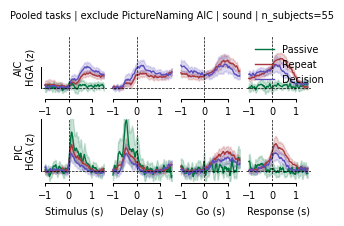

In [21]:
# Drop PictureNaming AIC from the pooled plot (keep PN PIC + all other tasks)
drop_mask = (
    (plot_df['task'] == 'PictureNaming')
    & (plot_df['roi'] == 'AIC')
)
plot_df_no_pn_aic = plot_df.loc[~drop_mask].copy()

n_aic_left = plot_df_no_pn_aic.loc[plot_df_no_pn_aic.roi == 'AIC', 'channel'].nunique()
print(
    f'Excluded rows: {int(drop_mask.sum()):,} | '
    f'remaining subjects: {plot_df_no_pn_aic.subject.nunique()} | '
    f'remaining AIC channels: {n_aic_left}'
)

fig = plot_condition_waveforms(
    plot_df_no_pn_aic,
    title=(
        f'Pooled tasks | exclude PictureNaming AIC | {MODALITY} | '
        f'n_subjects={plot_df_no_pn_aic.subject.nunique()}'
    ),
)

LexicalDelay: conditions=['Repeat', 'Decision'] | channels=157 | subjects=38


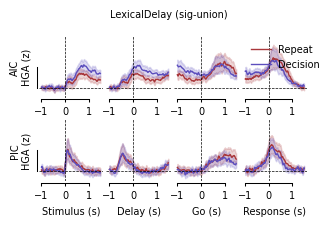

LexicalNoDelay: conditions=['Passive', 'Repeat', 'Decision'] | channels=51 | subjects=15


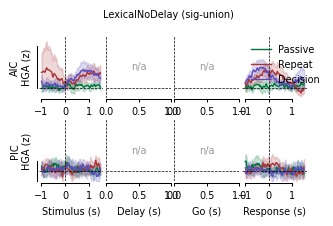

PhonemeSequence: conditions=['Repeat'] | channels=109 | subjects=31


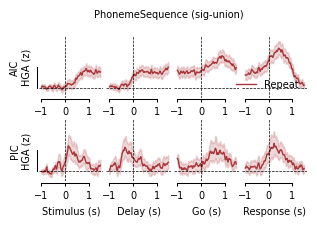

PictureNaming: conditions=['Passive', 'Repeat'] | channels=110 | subjects=25


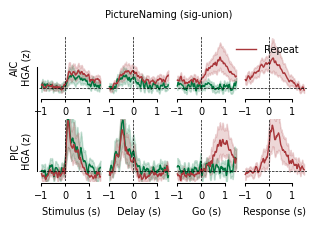

In [22]:
for task in TASKS:
    task_df = plot_df[plot_df['task'] == task] if len(plot_df) else pd.DataFrame()
    if task_df.empty:
        print(f'{task}: no rows — skip')
        continue
    _order = {d: i for i, d in enumerate(DESCRIPTIONS)}
    present = sorted(task_df['description'].unique(), key=lambda d: _order.get(d, 99))
    print(
        f'{task}: conditions={present} | '
        f'channels={task_df.channel.nunique()} | subjects={task_df.subject.nunique()}'
    )
    plot_condition_waveforms(
        task_df,
        descriptions=[d for d in DESCRIPTIONS if d in present],
        title=f'{task} (sig-union)',
    )